<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 9.2: CNN with Keras
INSTRUCTIONS:
- Read the guides and hints, then create the necessary analysis and code to find an answer and conclusion for the task below.
- A guide you are encouraged to read through is TensorFlow's own tutorial for image classification, which can be found [here](https://www.tensorflow.org/tutorials/images/cnn)

## CIFAR10 small image classification
- [CIFAR10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset of color training images, labeled over 10 categories.

It has the classes:
- airplane
- automobile
- bird
- cat
- deer
- dog
- frog
- horse
- ship
- truck

## Import libraries

In [98]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [100]:
## Import libraries
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix

In [102]:
# import tensorflow and keras
import tensorflow
from tensorflow import keras

from tensorflow.keras import datasets, layers, models

from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import MaxPool2D
from keras.layers import Flatten
from keras.layers import Dense

In [104]:
#Allow online monitoring with TensorBoard (need to be installed)
from keras.callbacks import TensorBoard

## Load data
Use the **Keras**' load method.

In [107]:
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

## Check some data

In [109]:
#Image normalisation
#Pixel values in CIFAR-10 range from 0 = black to 255 = white for each channel of RGB e.g. train_images[0][0][0]) could = [172, 123, 89])
#Normalize pixel values to be between 0 and 1 because NN works better on small scales
train_images, test_images = train_images / 255.0, test_images / 255.0 

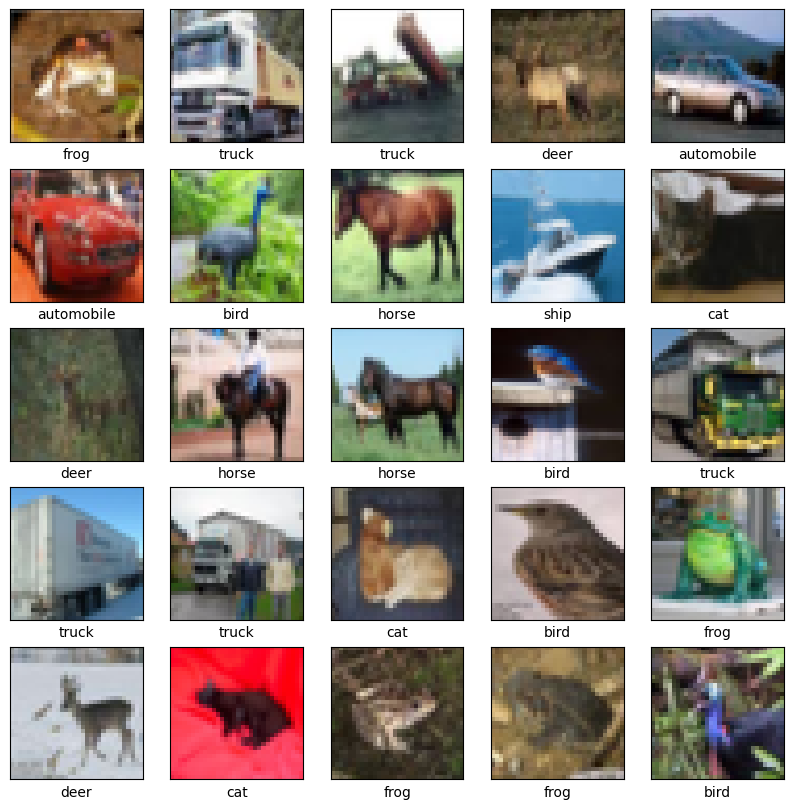

In [110]:
#Show the first 25 images from the training set with class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)  #the CIFAR labels happen to be arrays, which is why you need the extra index
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

## Prepare data

In [115]:
#Check if labels are one-hot encoded or integers
train_labels[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [117]:
#Integers, therefore use loss function 'sparse_categorical_crossentropy'

In [155]:
#See unique labels
print(np.unique(predictions_class, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([1154, 1303,  957, 1124, 1045,  769,  779, 1156,  848,  865]))


## Create the model's architecture
- **NOTE ALERT**: Take into account the volume of data and parameters. Time and processing escalate quite fast.
- **NOTE ALERT**: It is likely this data will require more complex models.

In [120]:
model = Sequential()

In [122]:
#These 6 lines define the convolutional base using a common pattern of Conv2D and MaxPooling 2D layers
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3))) #CIFAR-10 images are 32 x 32 pixels, therefore input shape (image_height, image_width, no. of color_channels) = (32, 32, 3)
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten()) #Flatten the 3D output to 1D, then add Dense layers on top
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax')) #10 classes in CIFAR-10

In [124]:
print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

None


In [126]:
#Every output of a Conv2D and MaxPooling2D layer is a 3D tensor (multi-dimensional array e.g. (3, 3, 3)) with shrinking height and width dimensions
#Conv2D params = (kernel_height × kernel_width × input_channels + 1) × number_of_filters = ((3 x 3 x 3) + 1) x 32
#MaxPooling2D params = 0 as it just reduces spatial dimensions
#Flatten params = 0 as it just reshapes 4 x 4 x 64 = 1024

## Compile the model

In [129]:
model.compile(optimizer='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Fit the training data

In [132]:
# Create a directory named 'logs' if it doesn't exist. This is necessary for TensorBoard to work
log_dir = 'logs'

if not os.path.exists(log_dir):
    os.makedirs(log_dir)

In [134]:
# Uncomment the statement below to allow online monitoring with TensorBoard
tensorboard = TensorBoard(log_dir = 'logs') # choose or create a directory for the logs

In [136]:
%%time
history = model.fit(
    train_images, 
    train_labels, 
    validation_split = 0.2,
    epochs=10, 
    callbacks = [tensorboard])

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - accuracy: 0.3424 - loss: 1.7845 - val_accuracy: 0.5254 - val_loss: 1.3212
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.5549 - loss: 1.2398 - val_accuracy: 0.5871 - val_loss: 1.1574
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.6260 - loss: 1.0594 - val_accuracy: 0.6438 - val_loss: 1.0287
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6662 - loss: 0.9520 - val_accuracy: 0.6561 - val_loss: 0.9951
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.6983 - loss: 0.8700 - val_accuracy: 0.6806 - val_loss: 0.9301
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7171 - loss: 0.8085 - val_accuracy: 0.6831 - val_loss: 0.9231
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7392 - loss: 0.7481 - val_accuracy: 0.7003 - val_loss: 0.8651
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.7567 -

### TensorBoard
- TensorBoard is TensorFlow's visualisation toolkit.
- If Tensorflow 2 and Jupyter is installed in the same environment, running the cell below will start TensorBoard within the notebook.
- More information about how to set up TensorBoard can be found [here](https://www.tensorflow.org/tensorboard/tensorboard_in_notebooks)


In [140]:
%load_ext tensorboard
%tensorboard --logdir logs

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 46283), started 0:49:46 ago. (Use '!kill 46283' to kill it.)

In [ ]:
# Uncomment and run the code below if unable to visualise TensorBoard a second time.
#%reload_ext tensorboard
#%tensorboard --logdir logs --port=6007

## Create predictions

In [142]:
predictions = model.predict(test_images)
predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


array([[3.53882824e-05, 1.77385082e-04, 2.36855078e-04, ...,
        2.36575142e-04, 5.13957697e-04, 1.41368306e-04],
       [9.33795469e-04, 4.86402869e-01, 1.31941886e-06, ...,
        4.29093827e-09, 5.11357009e-01, 1.29969383e-03],
       [3.44417952e-02, 4.71210107e-02, 1.36323087e-02, ...,
        1.43739739e-02, 7.94665635e-01, 5.26722781e-02],
       ...,
       [1.67927974e-05, 6.13897464e-06, 5.81720322e-02, ...,
        2.63270978e-02, 3.74703159e-05, 7.40227733e-06],
       [3.67969187e-05, 9.89017069e-01, 1.85635683e-04, ...,
        3.25380788e-05, 4.82944006e-06, 1.65338162e-03],
       [1.12362954e-07, 3.26247900e-08, 5.07356344e-06, ...,
        9.99304116e-01, 1.36118432e-08, 7.55352225e-09]], dtype=float32)

## Evaluate the model

In [144]:
score = model.evaluate(test_images, test_labels, batch_size=10)
print('\nTest loss: %.6f, Test accuracy: %.6f' % tuple(score))

1000/1000 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7037 - loss: 0.9103

Test loss: 0.927203, Test accuracy: 0.696500


In [146]:
#Define function to format confusion matrix
def print_cm(cm):
    d_size = max(len('%d' % cm.max()), len('%d' % cm.shape[1]))
    if min(cm.shape) > 10: # make sparse
        print('Sparse Matrix (*=diagonal)')
        fmt_c = ', c%%0%dd%%s= %%%dd' % (d_size, d_size)
        for i in range(cm.shape[0]):
            s = fmt_r % i
            for j in range(cm.shape[1]):
                if cm[i, j] > 0:
                    s += fmt_c % (j, '*' if i == j else ' ', cm[i, j])
            print(s)
    else: # make dense
        c = '%%%dd ' % d_size
        s = '%s| ' % (' ' * d_size)
        s += ''.join([c % i for i in range(len(cm[0]))])
        print(s)
        print('-' * len(s))
        for i, r in enumerate(cm):
            s = '%%%dd| ' % d_size
            s = s % i
            s += c * len(r)
            print(s % tuple(r))

In [158]:
#Create confusion matrix, row is actual labels and column is predicted labels
predictions_class = np.argmax(predictions, axis=1) #Convert predicted probabilities to class labels
cm = confusion_matrix(test_labels, predictions_class)
print_cm(cm)

   |   0   1   2   3   4   5   6   7   8   9 
---------------------------------------------
  0| 788  50  43   9  20   4   2  16  45  23 
  1|  17 916   5   6   1   2   3   2  13  35 
  2|  88  17 582  80  89  48  28  46  12  10 
  3|  40  16  73 561  71 120  25  62  10  22 
  4|  27   9  63  68 669  16  26 110   6   6 
  5|  22  10  74 217  58 518   7  75   6  13 
  6|  18  16  56 123  54  18 683  21   1  10 
  7|  12   8  36  32  60  31   1 806   3  11 
  8|  89  86  17  14  15   7   2   5 736  29 
  9|  53 175   8  14   8   5   2  13  16 706 


## Visualisation of cost

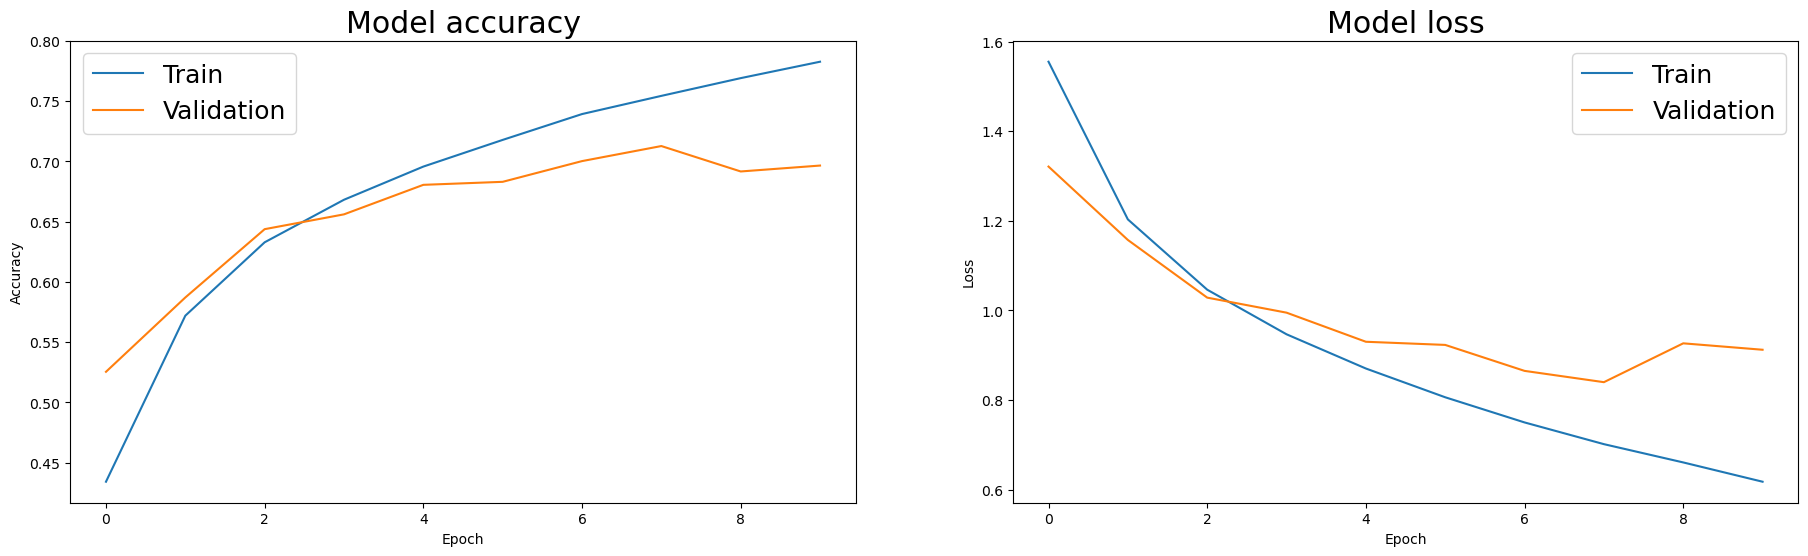

In [153]:
fig, ax = plt.subplots(1, 2, figsize = (18, 6))
fig.subplots_adjust(left = 0.02, right = 0.98, wspace = 0.2)

plt.rcParams.update({'font.size': 18})

# Plot training & validation accuracy values
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Model accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(['Train', 'Validation'])

# Plot training & validation loss values
ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Model loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(['Train', 'Validation'])

plt.show()

Interpretation:
- Generally, model accuracy improved and loss diminished with more epochs, suggesting the model was successfully learning the patterns
- However, train accuracy and validation loss increased after epoch 2, suggesting overfitting
- This could be remedied by early stopping where validation loss is at a min., regularisation, increasing data or simplifying the model

## Results

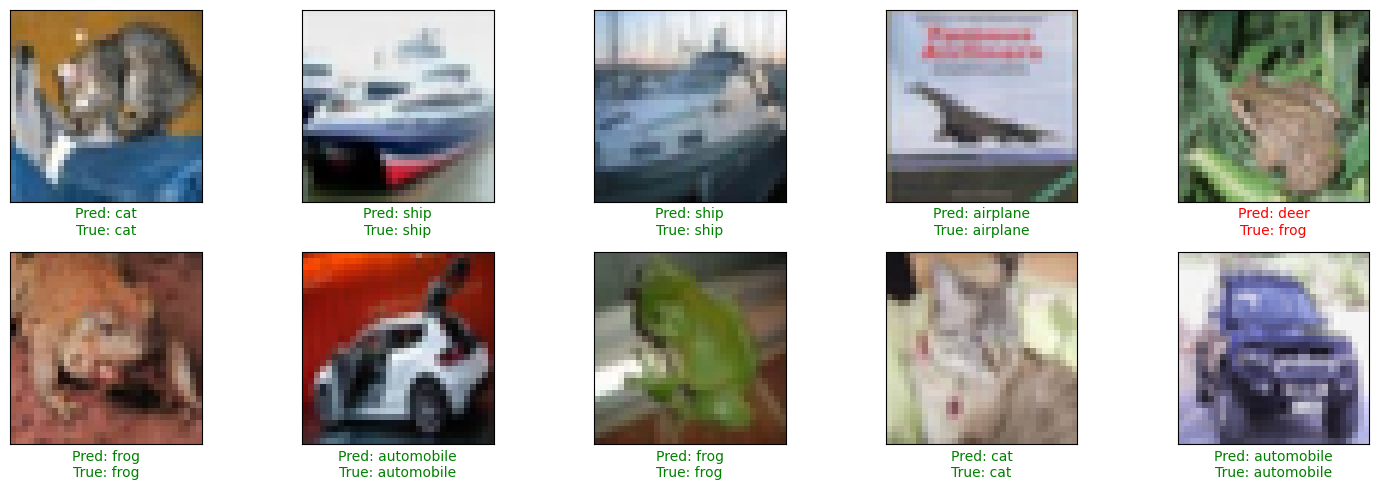

In [182]:
#Compare predicted and actual for a sample of 10
num_images = 10
plt.figure(figsize=(15, 5))

for i in range(num_images):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i])
    
    predicted_label = class_names[predictions_class[i]]
    true_label = class_names[test_labels[i][0]]
    
    color = 'green' if predicted_label == true_label else 'red'
    plt.xlabel(f'Pred: {predicted_label}\nTrue: {true_label}', color=color)

plt.tight_layout()
plt.show()



---



---



> > > > > > > > > © 2025 Institute of Data


---



---



